#***RANDOMFOREST***

This notebook trains and evaluates a Random Forest model for underwater acoustic classification.

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Import libraries:

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

Mount Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define Path:

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Underwater Audio Data")

DATA_DIR = PROJECT_DIR / "splits"                   #Here we use the data before scaling, because randomforest doesnt require scaling.

MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Data:

In [ ]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")                         #Unscaled features used

X_test = pd.read_csv(DATA_DIR / "X_test.csv")                           #unscaled features used

y_train = pd.read_csv(DATA_DIR / "y_train.csv")

y_test = pd.read_csv(DATA_DIR / "y_test.csv")

Converts labels to series:

In [ ]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

Verify Shape:

In [ ]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (6086, 155)
Testing Features : (1811, 155)

Training Labels : (6086,)
Testing Labels : (1811,)


Create the model:

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

Train the model:

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

Make predictions:

In [ ]:
y_pred = model.predict(X_test)

Accuracy:

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8316


Precision, Recall, F1-score:

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Precision : 0.8429
Recall    : 0.8316
F1 Score  : 0.8166


Classification Report:

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Ambience       0.83      0.39      0.53       360
  Biological       0.69      0.93      0.79       500
     Vessels       0.93      0.95      0.94       951

    accuracy                           0.83      1811
   macro avg       0.82      0.75      0.75      1811
weighted avg       0.84      0.83      0.82      1811



Confusion matrix:

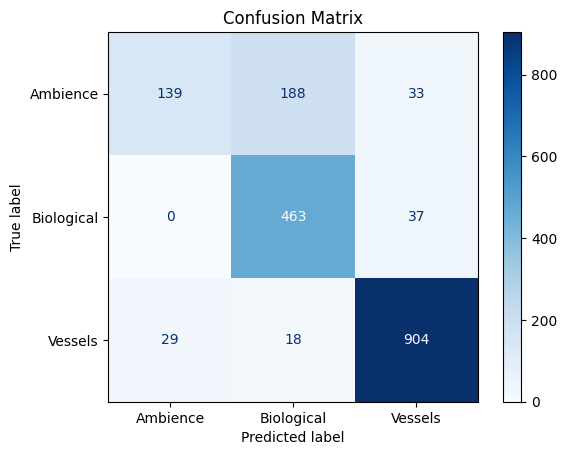

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Saave the model:

In [ ]:
joblib.dump(model, MODEL_DIR / "random_forest.pkl")

print("Model saved successfully.")

Model saved successfully.


FINAL SUMMARY

In [ ]:
print("=" * 60)

print("RANDOM FOREST COMPLETED")

print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print("Model saved to:")

print(MODEL_DIR / "random_forest.pkl")

RANDOM FOREST COMPLETED
Accuracy : 0.8316
Precision: 0.8429
Recall   : 0.8316
F1 Score : 0.8166

Model saved to:
/content/drive/MyDrive/Underwater Audio Data/models/logistic_regression.pkl
